# 04 — Optuna hyperparameter optimization

**Estimated time:** 120–160 minutes  
**Prerequisites:** notebooks 00–03; gradient boosting, CV, and early stopping.  
**Depends on:** the development/validation/test contract from notebook 00.

## Learning objectives

- Translate model-development goals into an Optuna objective.
- Design a bounded, reproducible search space for CatBoost.
- Combine cross-validation, early stopping, and Optuna pruning without leakage.
- Inspect trials, parameter importance, and optimization history.
- Promote one tuned candidate to validation without repeatedly optimizing validation.


In [1]:
import hashlib, json, os, platform, random, warnings
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
# Known interoperability/UI warnings do not affect predictions or notebook execution.
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (balanced_accuracy_score, brier_score_loss, confusion_matrix,
                             f1_score, log_loss, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

def project_root():
    '''Return the course root when present, otherwise the notebook directory.'''
    # Return the course root when present, otherwise the notebook's directory.
    return ROOT

def set_seed(seed=SEED):
    '''Seed Python and NumPy RNGs for reproducible notebook runs.'''
    random.seed(seed)
    np.random.seed(seed)

def fast_mode():
    '''Report whether notebooks should use the reduced fast-mode sample.'''
    # Set FAST_MODE=0 for full-size experiments; laptop mode is the default.
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}

def bank_data_path():
    '''Locate the bundled Bank Marketing CSV file.'''
    # The course ships with a local dataset; notebooks never access the network.
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected the bundled Bank Marketing data at {path}. "
            "Run the notebook from the course root or place bank-full.csv there."
        )
    return path

def file_sha256(path):
    '''Compute the SHA-256 digest of a local file.'''
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_bank_data(include_duration=False):
    '''Load the Bank Marketing dataset and drop leakage columns by default.'''
    # Load the data, encode y, and exclude post-call duration by default.
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame

def stratified_sample(frame, n, seed=SEED):
    '''Draw a label-preserving sample from a classified dataset.'''
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [group.sample(n=min(counts.loc[label], len(group)),
                          random_state=seed + int(label))
             for label, group in frame.groupby(TARGET)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def make_splits(frame=None, reduced=None):
    '''Create deterministic stratified train, validation, and test splits.'''
    # Deterministic stratified 60/20/20 split; test stays sealed until notebook 09.
    from sklearn.model_selection import train_test_split
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED)
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

def split_xy(frame):
    '''Separate a frame into feature matrix and target vector.'''
    return frame.drop(columns=TARGET), frame[TARGET]

def feature_groups(frame):
    '''Identify numeric and categorical feature columns.'''
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical

def make_preprocessor(frame, scale_numeric=True):
    '''Build the preprocessing pipeline for numeric and categorical features.'''
    # Preprocessing is fitted only inside the enclosing training/CV pipeline.
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                 min_frequency=10, sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

def classification_metrics(y_true, probability, threshold=0.5):
    '''Compute ranking and threshold-based classification metrics.'''
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"log_loss": log_loss(y_true, probability),
            "brier_score": brier_score_loss(y_true, probability),
            "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
            "f1": f1_score(y_true, prediction, zero_division=0),
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "cost": float(fp + 5 * fn)}

def threshold_table(y_true, probability, thresholds=None):
    '''Evaluate classification metrics across a list of decision thresholds.'''
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([{"threshold": float(t),
                          **classification_metrics(y_true, probability, float(t))}
                         for t in thresholds])

def add_domain_features(frame):
    '''Create domain-inspired features for the Bank Marketing dataset.'''
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(result["age"], bins=[0, 29, 39, 49, 59, np.inf],
                                labels=["<30", "30s", "40s", "50s", "60+"]).astype("object")
    return result.drop(columns=["pdays"])

def environment_metadata():
    '''Collect runtime metadata for experiment tracking.'''
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "numpy": np.__version__, "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__}

def write_json(data, path):
    '''Serialize structured data to a JSON file on disk.'''
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")

set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
BRAND_COLOR = "#2a9d8f"
ACCENT_COLOR = "#e76f51"
sns.set_theme(style="whitegrid", context="notebook", palette=[BRAND_COLOR, ACCENT_COLOR, "#264653", "#f4a261"])
plt.rcParams.update({
    "axes.facecolor": "#fcfcfc",
    "figure.facecolor": "white",
    "axes.edgecolor": "#d9d9d9",
    "grid.color": "#e8e8e8",
    "grid.linewidth": 0.8,
    "axes.titleweight": "bold",
    "axes.labelweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})


{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


In [2]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

development, validation, _sealed_test = make_splits(load_bank_data(), reduced=FAST_MODE)
X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)
import catboost
print("Library versions:", catboost.__version__)


Library versions: 1.2.8


## What Optuna is responsible for

Optuna is not a magic model improver. It is a controlled experiment runner for model-development
choices: propose parameters, fit a candidate under the same data boundary, observe a metric, and
use the trial history to choose the next candidate.

In this notebook the model is CatBoost, but the center of gravity is Optuna:

- the objective returns cross-validated log loss from development data only;
- each fold owns its own preprocessing and early-stopping split;
- the search space is intentionally bounded because search budget is limited;
- pruning can stop weak trials after partial evidence;
- validation is used once after the study to compare the tuned candidate with the baseline.


In [3]:
# A single untuned baseline gives Optuna something honest to beat.
preprocessor = make_preprocessor(development, scale_numeric=False)
X_dev_encoded = preprocessor.fit_transform(X_dev, y_dev)
X_val_encoded = preprocessor.transform(X_val)

catboost_baseline = CatBoostClassifier(
    loss_function="Logloss", eval_metric="Logloss", iterations=1000,
    learning_rate=0.04, depth=6, min_data_in_leaf=30,
    l2_leaf_reg=3.0, random_seed=SEED, thread_count=-1,
    allow_writing_files=False, verbose=False,
)
catboost_baseline.fit(
    X_dev_encoded, y_dev, eval_set=[(X_val_encoded, y_val)],
    use_best_model=True, early_stopping_rounds=50, verbose=False,
)
cat_p = catboost_baseline.predict_proba(X_val_encoded)[:, 1]
print("CatBoost best iteration:", catboost_baseline.get_best_iteration())
pd.Series(classification_metrics(y_val, cat_p), name="untuned CatBoost")


CatBoost best iteration: 336


log_loss                0.279744
brier_score             0.080282
balanced_accuracy       0.610379
f1                      0.348509
precision               0.656805
recall                  0.237179
specificity             0.983579
cost                 1843.000000
Name: untuned CatBoost, dtype: float64

## Design the Optuna study

The objective below uses only development folds. Each fold fits its own encoder and uses its
validation fold for early stopping. The trial reports intermediate mean log loss after each fold,
enabling Optuna's median pruner. The sealed test set is absent from the function, and the
validation set is also absent from the objective.

`FAST_MODE=1` runs 8 trials × 3 folds; full mode runs 25 × 5. This is an educational search,
not evidence that 25 trials fully explores the space.

### Search-space choices

| Parameter | Why Optuna tunes it | Bound used here |
|---|---|---|
| `learning_rate` | shrinkage/iteration tradeoff | log scale, 0.02–0.12 |
| `depth` | tree depth and interaction complexity | 4–8 |
| `min_data_in_leaf` | leaf regularization | 10–80 |
| `subsample` | row sampling regularization | 0.70–1.00 |
| `rsm` | feature sampling regularization | 0.70–1.00 |
| `l2_leaf_reg`, `random_strength` | regularization and split-score noise | log-scaled positive ranges |


In [4]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def objective(trial):
    # Return development-only cross-validated log loss for one Optuna trial.
    params = {
        "loss_function": "Logloss", "eval_metric": "Logloss",
        "thread_count": -1, "random_seed": SEED, "iterations": 800,
        "allow_writing_files": False, "verbose": False,
        "bootstrap_type": "Bernoulli",
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 80),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "rsm": trial.suggest_float("rsm", 0.7, 1.0),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 5.0, log=True),
    }
    fold_scores = []
    for fold, (fit_idx, stop_idx) in enumerate(cv.split(X_dev, y_dev)):
        X_fit, X_stop = X_dev.iloc[fit_idx], X_dev.iloc[stop_idx]
        y_fit, y_stop = y_dev.iloc[fit_idx], y_dev.iloc[stop_idx]
        fold_pre = make_preprocessor(development.iloc[fit_idx], scale_numeric=False)
        X_fit_e = fold_pre.fit_transform(X_fit, y_fit)
        X_stop_e = fold_pre.transform(X_stop)
        model = CatBoostClassifier(**params)
        model.fit(X_fit_e, y_fit, eval_set=[(X_stop_e, y_stop)],
                  use_best_model=True, early_stopping_rounds=35, verbose=False)
        fold_scores.append(log_loss(y_stop, model.predict_proba(X_stop_e)[:, 1]))
        trial.report(float(np.mean(fold_scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_scores))

study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3),
)
study.optimize(objective, n_trials=8 if FAST_MODE else 25, timeout=180 if FAST_MODE else 900)
print("best CV log loss:", round(study.best_value, 4))
display(pd.Series(study.best_params, name="best parameter"))


best CV log loss: 0.2934


learning_rate        0.057812
depth                4.000000
min_data_in_leaf    53.000000
subsample            0.751157
rsm                  0.719515
l2_leaf_reg          7.025166
random_strength      3.731160
Name: best parameter, dtype: float64

,number,value,state,params_depth,params_l2_leaf_reg,params_learning_rate,params_min_data_in_leaf,params_random_strength,params_rsm,params_subsample,duration
0,0,0.300832,COMPLETE,8,0.029375,0.039127,61,0.001640,0.746806,0.879598,0 days 00:00:01.492456
5,5,0.297146,PRUNED,5,0.023234,0.085131,16,0.067865,0.832046,0.905270,0 days 00:00:00.338756
3,3,0.295396,PRUNED,5,0.039721,0.025679,36,0.079825,0.935553,0.836821,0 days 00:00:00.606427
6,6,0.295260,COMPLETE,8,0.363249,0.021271,28,0.105260,0.793513,0.898757,0 days 00:00:03.089489
7,7,0.294182,PRUNED,8,0.621870,0.027853,65,2.570308,0.968448,0.981850,0 days 00:00:01.441667
2,2,0.293966,COMPLETE,4,0.074763,0.027702,31,0.183327,0.829584,0.857427,0 days 00:00:02.080035
1,1,0.293911,COMPLETE,7,3.142881,0.094416,60,0.006101,0.990973,0.706175,0 days 00:00:01.130016
4,4,0.293392,COMPLETE,4,7.025166,0.057812,53,3.731160,0.719515,0.751157,0 days 00:00:01.968642


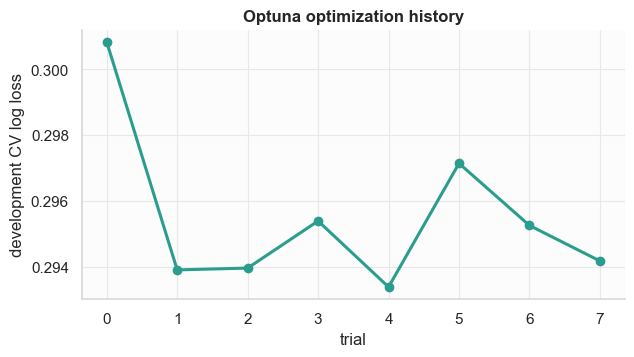

In [5]:
trials = study.trials_dataframe(attrs=("number", "value", "state", "params", "duration"))
trials = trials.sort_values("value", ascending=False, na_position="last")
display(trials.head(10))

ax = study.trials_dataframe(attrs=("number", "value")).plot(
    x="number", y="value", marker="o", legend=False, figsize=(7, 3.5),
    color=BRAND_COLOR, linewidth=2.2,
)
ax.set_title("Optuna optimization history")
ax.set_xlabel("trial")
ax.set_ylabel("development CV log loss")
plt.show()


,parameter,importance
0,subsample,0.251760
1,l2_leaf_reg,0.181076
2,min_data_in_leaf,0.179361
3,depth,0.150362
4,learning_rate,0.095064
5,random_strength,0.081483
6,rsm,0.060894


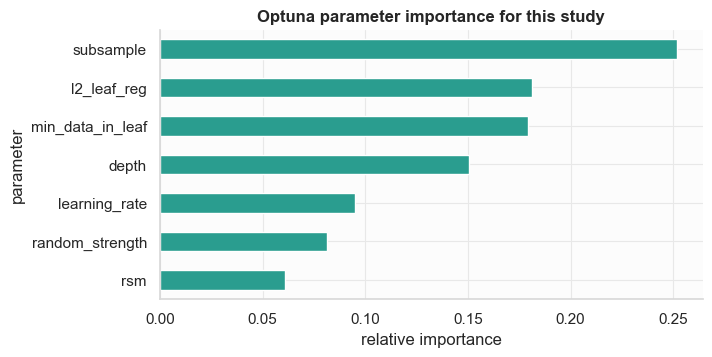

In [6]:
try:
    importances = optuna.importance.get_param_importances(study)
    importance_frame = (
        pd.Series(importances, name="importance")
        .rename_axis("parameter")
        .reset_index()
        .sort_values("importance", ascending=True)
    )
    display(importance_frame.sort_values("importance", ascending=False))
    importance_frame.plot.barh(
        x="parameter", y="importance", legend=False, figsize=(7, 3.5), color=BRAND_COLOR,
    )
    plt.title("Optuna parameter importance for this study")
    plt.xlabel("relative importance")
    plt.show()
except Exception as exc:
    print(f"Parameter importance skipped: {exc}")


In [7]:
tuned_params = {
    **study.best_params, "loss_function": "Logloss", "eval_metric": "Logloss",
    "thread_count": -1, "random_seed": SEED, "iterations": 1200,
    "allow_writing_files": False, "verbose": False, "bootstrap_type": "Bernoulli",
}
tuned = CatBoostClassifier(**tuned_params)
tuned.fit(X_dev_encoded, y_dev, eval_set=[(X_val_encoded, y_val)],
          use_best_model=True, early_stopping_rounds=50, verbose=False)
tuned_p = tuned.predict_proba(X_val_encoded)[:, 1]
validation_comparison = pd.DataFrame({
    "untuned CatBoost": classification_metrics(y_val, cat_p),
    "Optuna CatBoost": classification_metrics(y_val, tuned_p),
}).T
validation_comparison


,log_loss,brier_score,balanced_accuracy,f1,precision,recall,specificity,cost
untuned CatBoost,0.279744,0.080282,0.610379,0.348509,0.656805,0.237179,0.983579,1843.0
Optuna CatBoost,0.280983,0.080559,0.610534,0.346095,0.610811,0.241453,0.979615,1847.0


A tiny validation gain may not survive sampling variation and may not justify added search cost.
Trial histories are adaptive; the best CV score is optimistically selected. Final claims wait for
notebook 09's one-time test evaluation.

## Common mistakes and leakage warnings

- Optimizing Optuna against validation repeatedly or against test even once.
- Fitting one encoder before CV and reusing it across folds.
- Letting early stopping inspect the same rows used to fit trees.
- Searching huge spaces with too few trials, then overinterpreting the winner.
- Treating parameter importance as universal truth instead of study-specific diagnostics.
- Retuning the search space after looking at validation until the validation result improves.

## Exercises

1. Plot Optuna parameter importance and explain why it is study-specific.
2. Add a time budget and compare the best-so-far curve across two seeded studies.
3. Add `scale_pos_weight` to the search space and explain how it changes threshold behavior.
4. **Challenge:** implement nested CV for unbiased tuning-performance estimation and state its
   computational cost.

## Summary

Optuna turns hyperparameter tuning into a reproducible study: define the objective, bound the
search space, prune weak trials, inspect diagnostics, and promote one candidate. The objective
stays inside the development boundary. Validation compares finalists, while test evaluation
remains deferred.

## References

- [Optuna first optimization](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/001_first.html)
- [Optuna efficient optimization](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html)
- [Optuna pruning](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html#pruning-algorithms)
- [CatBoostClassifier](https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier)
